## __Theoretical Model__

### _Assumptions:_

1. Incompressibility: cell area constant

2. Boundary conditions: basal vertices are bounded to the inital wavy layer

3. Confluent conditions: first and last cell are fixed

4. Density (Number of cell per wavelength) is kept constant

### _Hamiltonian of the system_:

$H(x, y) = \sum_{cell} \Gamma_a d_{a, cell} + \Gamma_l d_{l, cell} + K(A_{cell} - A_0)^2$

- $\Gamma_a$: apical tension
- $d_a$: apical distance
- $\Gamma_l$: lateral tension
- $d_l$: lateral distance
- $K$: compressibility modulus
- $A_0$: preferred cell area 

### _Forces_:
 
$F_x = -\nabla_x H(x, y), \quad F_y = -\nabla_y H(x, y)$

### __EVALUATE AREAS__

The area of a cell (trapezoid made up of 4 vertices) is evaluated according to the formula:
    $$ A_{cell} = \frac{1}{2} |{\sum_{i=0}^{3} (x_iy_{i+1} - x_{i+1}y_{i})}| $$

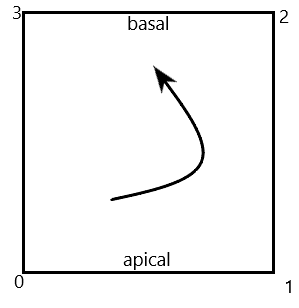

In [5]:
from IPython.display import Image
Image(filename='vertex.png')

In [ ]:
import numpy as np
def evaluate_areas(self):
        areas = np.zeros((self.N_cells, 1))
        j = 0
        for vertex in range(self.N_cells):
            x_coord = np.array([self.apical[vertex, 0], self.apical[(vertex + 1) % self.N_cells, 0], self.basal[(vertex + 1) % self.N_cells, 0], self.basal[vertex, 0]])
            y_coord = np.array([self.apical[vertex, 1], self.apical[(vertex + 1) % self.N_cells, 1], self.basal[(vertex + 1) % self.N_cells, 1], self.basal[vertex, 1]])
            A_cell = 0
            for i in range(len(x_coord)):
                A_cell += x_coord[i]*y_coord[(i+1) % len(x_coord)] - x_coord[(i+1) % len(x_coord)]*y_coord[i]
            areas[j] = np.abs(A_cell)*0.5
            j+=1
        return areas

x_coord = [x_0, x_1, x_2, x_3]
y_coord = [y_0, y_1, y_2, y_3]

$$ A_{cell} =\frac{1}{2}[(x_0y_1 - x_1y_0) + (x_1y_2 - x_2y_1) + (x_2y_3 - x_3y_2) + (x_3y_0 - x_0y_3)] $$ 

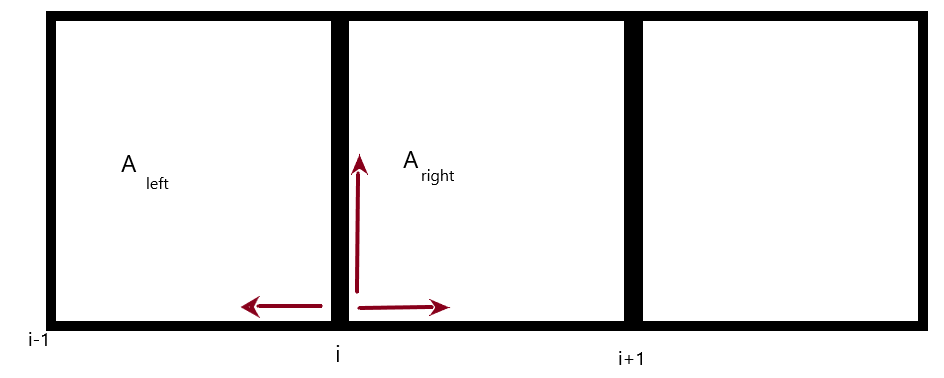

In [6]:
from IPython.display import Image
Image(filename='vertex_for_forces.png') 

## __DISCRETE ENERGY__

$$ H_{cell} = \Gamma_a (d_{apical,left} + d_{apical, right}) + \Gamma_l d_{lateral} + K(A_{cell} - A_0)^2 $$

$$d_{apical,left} = \sqrt{(x_{i, apical} - x_{i-1, apical})^2 + (y_{i, apical} - y_{i-1, apical})^2}$$
$$d_{apical, right} = \sqrt{(x_{i, apical} - x_{i+1, apical})^2 + (y_{i, apical} - y_{i+1, apical})^2}$$
$$d_{lateral} = \sqrt{(x_{i, apical} - x_{i, basal})^2 + (y_{i, apical} - y_{i, basal})^2} $$

## __EVALUATE FORCES__

# Apical side:
  $$ F_{x_{i, apical}} = -\frac{dH}{dx_{i, apical}} = -\Gamma_l (\frac{(x_{i, apical} - x_{i, basal})}{d_{lateral}}) + \\
                                                      -\Gamma_a (\frac{(x_{i, apical} - x_{i-1, apical})}{d_{apical,left}} + \frac{(x_{i, apical} - x_{i+1, apical})}{d_{apical,right}}) +\\
                                                      - K[(A_{cell, left} - A0_{cell, left})(y_{i, basal} - y_{i-1, apical}) + (A_{cell, right} - A0_{cell, right})(y_{i+1, apical} - y_{i, basal})] $$

  $$ F_{y_{i, apical}} = -\frac{dH}{dx_{i, apical}} = -\Gamma_l (\frac{(y_{i, apical} - y_{i, basal})}{d_{lateral}}) + \\
                                                      -\Gamma_a (\frac{(y_{i, apical} - y_{i-1, apical})}{d_{apical,left}} + \frac{(y_{i, apical} - y_{i+1, apical})}{d_{apical,right}}) +\\
                                                      - K[(A_{cell, left} - A0_{cell, left})(x_{i-1, apical} - x_{i, basal}) + (A_{cell, right} - A0_{cell, right})(x_{i, basal} - x_{i+1, apical})] $$
      
  
  # Basal side:
  $$ F_{x_{i, apical}} = -\frac{dH}{dx_{i, apical}} = -\Gamma_l (\frac{(x_{i, apical} - x_{i, basal})}{d_{lateral}}) + \\
                                                      - K[(A_{cell, left} - A0_{cell, left})(y_{i, apical} - y_{i-1, basal}) + (A_{cell, right} - A0_{cell, right})(y_{i+1, basal} - y_{i, apical})] $$

  $$ F_{y_{i, apical}} = -\frac{dH}{dx_{i, apical}} = -\Gamma_l (\frac{(y_{i, apical} - y_{i, basal})}{d_{lateral}}) + \\
                                                      - K[(A_{cell, left} - A0_{cell, left})(x_{i-1, basal} - x_{i, apical}) + (A_{cell, right} - A0_{cell, right})(x_{i, apical} - x_{i+1, basal})] $$
      
  

In [ ]:
def forces(self, side, vertex):
        fx = np.zeros((self.N_cells, 1))
        fy =  np.zeros((self.N_cells, 1))
        dist_sx, dist_dx, dist_lateral = self.distances(self.apical[vertex, 0], self.apical[vertex, 1], self.basal[vertex, 0], self.basal[vertex, 1], vertex, side)
        if side == 'apical':
            
            #lateral contribution
            fx[vertex] = -self.lateral_tension*((self.apical[vertex, 0] - self.basal[vertex, 0]) / dist_lateral) 
            fy[vertex] = -self.lateral_tension*((self.apical[vertex, 1] - self.basal[vertex, 1]) / dist_lateral)

            #right and left apical length contribution
            fx[vertex] -= self.apical_tension*((self.apical[vertex, 0] - self.apical[(vertex + 1) % self.N_cells, 0]) / dist_dx) 
            fx[vertex] -= self.apical_tension*((self.apical[vertex, 0] - self.apical[(vertex - 1) % self.N_cells, 0]) / dist_sx)
            fy[vertex] -= self.apical_tension*((self.apical[vertex, 1] - self.apical[(vertex + 1) % self.N_cells, 1]) /dist_dx)
            fy[vertex] -= self.apical_tension*((self.apical[vertex, 1] - self.apical[(vertex - 1) % self.N_cells, 1])/ dist_sx)
            
            #right and left area contribution
            if self.compress_cell > 0:
                x_coord1 = np.array([self.apical[vertex, 0], self.apical[(vertex + 1) % self.N_cells, 0], self.basal[(vertex + 1) % self.N_cells, 0], self.basal[vertex, 0]])
                y_coord1 = np.array([self.apical[vertex, 1], self.apical[(vertex + 1) % self.N_cells, 1], self.basal[(vertex + 1) % self.N_cells, 1], self.basal[vertex, 1]])
                x_coord2 = np.array([self.apical[vertex, 0], self.basal[vertex, 0], self.basal[(vertex - 1) % self.N_cells, 0], self.apical[(vertex - 1) % self.N_cells, 0]])
                y_coord2 = np.array([self.apical[vertex, 1], self.basal[vertex, 1], self.basal[(vertex - 1) % self.N_cells, 1], self.apical[(vertex - 1) % self.N_cells, 1]])
                A_cell2 = 0
                A_cell1 = 0
                for i in range(len(x_coord1)):
                    A_cell1 += x_coord1[i]*y_coord1[(i+1) % len(x_coord1)] - x_coord1[(i+1) % len(x_coord1)]*y_coord1[i]
                    A_cell2 += x_coord2[i]*y_coord2[(i+1) % len(x_coord1)] - x_coord2[(i+1) % len(x_coord1)]*y_coord2[i]
                
                fx[vertex] -= self.compress_cell*(0.5*np.abs(A_cell1) - self.A0[vertex])*(-self.basal[vertex, 1] + self.apical[(vertex+1)%self.N_cells, 1])
                fy[vertex] -= self.compress_cell*(0.5*np.abs(A_cell1) - self.A0[vertex])*(self.basal[vertex, 0] - self.apical[(vertex+1)%self.N_cells, 0])
                fx[vertex] -= self.compress_cell*(0.5*np.abs(A_cell2) - self.A0[(vertex - 1) % self.N_cells])*(self.basal[vertex, 1] - self.apical[(vertex-1)%self.N_cells, 1])
                fy[vertex] -= self.compress_cell*(0.5*np.abs(A_cell2) - self.A0[(vertex - 1) % self.N_cells])*(-self.basal[vertex, 0] + self.apical[(vertex-1)%self.N_cells, 0])
        else:

            #lateral contribution
            fx[vertex] = -self.lateral_tension*((self.basal[vertex, 0] - self.apical[vertex, 0]) / dist_lateral)
            fy[vertex] = -self.lateral_tension*((self.basal[vertex, 1] - self.apical[vertex, 1]) / dist_lateral)
            
            #right and left area contribution
            if self.compress_cell > 0:
                x_coord1 = np.array([self.apical[vertex, 0], self.apical[(vertex + 1) % self.N_cells, 0], self.basal[(vertex + 1) % self.N_cells, 0], self.basal[vertex, 0]])
                y_coord1 = np.array([self.apical[vertex, 1], self.apical[(vertex + 1) % self.N_cells, 1], self.basal[(vertex + 1) % self.N_cells, 1], self.basal[vertex, 1]])
                x_coord2 = np.array([self.apical[vertex, 0], self.basal[vertex, 0], self.basal[(vertex - 1) % self.N_cells, 0], self.apical[(vertex - 1) % self.N_cells, 0]])
                y_coord2 = np.array([self.apical[vertex, 1], self.basal[vertex, 1], self.basal[(vertex - 1) % self.N_cells, 1], self.apical[(vertex - 1) % self.N_cells, 1]])
                A_cell2 = 0
                A_cell1 = 0
                for i in range(len(x_coord1)):
                    A_cell1 += x_coord1[i]*y_coord1[(i+1) % len(x_coord1)] - x_coord1[(i+1) % len(x_coord1)]*y_coord1[i]
                    A_cell2 += x_coord2[i]*y_coord2[(i+1) % len(x_coord1)] - x_coord2[(i+1) % len(x_coord1)]*y_coord2[i]
                
                fx[vertex] -= self.compress_cell*(0.5*np.abs(A_cell1) - self.A0[vertex])*(-self.basal[(vertex+1)%self.N_cells, 1] + self.apical[vertex, 1])
                fy[vertex] -= self.compress_cell*(0.5*np.abs(A_cell1) - self.A0[vertex])*(self.basal[(vertex+1)%self.N_cells, 0] - self.apical[vertex, 0])
                fx[vertex] -= self.compress_cell*(0.5*np.abs(A_cell2) - self.A0[(vertex - 1) % self.N_cells])*(-self.apical[vertex, 1] + self.basal[(vertex-1)%self.N_cells, 1])
                fy[vertex] -= self.compress_cell*(0.5*np.abs(A_cell2) - self.A0[(vertex - 1) % self.N_cells])*(self.apical[vertex, 0] - self.basal[(vertex-1)%self.N_cells, 0])
                
        return fx, fy